# Forecasting methods, compared where the comparison is visible

`CODE.ipynb` answers "what does a forecast buy a home battery". This notebook
answers three questions it raises and cannot show:

1. **Do its correlation figures show the statistic they print?** Three of them are
   drawn here in the space their own test measures, under their existing export
   names, so the LaTeX side does not move.
2. **Which of the top methods should a household actually run?** The roster figure
   ranks fourteen arms on one axis; the two that win are one percentage point
   apart on it. Head to head, they **swap between the tariffs**, and both swaps
   clear a paired test.
3. **When does a forecast break?** Not on the days a calendar marks — public
   holidays do not move these households at all. On the days the household is
   away, which nothing in the model can know, and where Prophet throws away
   **34 %** of the day's achievable saving against 9 % on a normal day.

Everything runs off the caches `CODE.ipynb`'s sweep already wrote: no MILP, no
Prophet fits, about twenty seconds cold in this kernel. The shared style lives in
`figure_style.py` and the anomaly machinery in `anomaly.py`, both imported by
this notebook and the first one, so the two cannot drift.

In [1]:
### Setup: the same frames CODE.ipynb builds, plus the daily panel
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from scipy import stats as st
import textwrap

import hems_study as hs
import figure_style as fs
import anomaly as an
hs, fs, an = (importlib.reload(m) for m in (hs, fs, an))

import Plotting_Functions as pf
pf = importlib.reload(pf)
# The SAME style CODE.ipynb sets, from the same call, writing into the same
# export directory -- so a figure reworked here lands on the LaTeX side under
# the name it already had, and a new one lands beside it.
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, finish

N_SIM = 365

# THE SAME PANEL, BUILT THE SAME WAY. This block is CODE.ipynb's cells 5 and 7
# with the printing removed: results in, stale checkpoints out, households that
# did not finish every arm out, then `summarize`. It is duplicated rather than
# imported because a notebook that loads a frame someone else balanced cannot
# say what it is looking at -- and the balance rule is one of the study's
# invariants, not a detail.
df_all = hs.collect_results(hs.RESULTS_DIR)
df_all = df_all[df_all["roster_complete"]].reset_index(drop=True)
_arms = sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index)
_done = df_all.groupby("dataset")["arm"].nunique()
_held = set(df_all["dataset"]) - set(_done[_done == len(_arms)].index)
if _held:
    print(f"Held out to keep the panel balanced: {len(_held)} -- "
          f"{', '.join(sorted(_held))}")
df_all = df_all[~df_all["dataset"].isin(_held)].reset_index(drop=True)
long = hs.summarize(df_all)

# The forecast error table, read rather than rescored: every arm above has
# already warmed the caches it needs. `provenance` names any column that
# disagrees with what this notebook believes, which is the check that stops a
# table scored over 90 days being described as 365.
bench = pd.read_csv(Path(hs.RESULTS_DIR) / "forecast_benchmark.csv")
_order = [k for k in hs.FORECAST_KIND_LABELS if k in set(bench["kind"])]
bench["kind"] = pd.Categorical(bench["kind"], categories=_order, ordered=True)

ARM_FOR = {t: hs.forecast_arms(t) for t in sorted(set(df_all["tariff"]))}
SAMPLE = f"{df_all['dataset'].nunique()} households, one per k-means cluster"
LABEL = {c: hs.controller_label(c, 48, 0.5, N_SIM) for c in hs.CONTROLLER_ALGORITHM}

# THE DAILY PANEL: one row per (household, day) with each method's daily error
# and, on AU, the day's money. About 15 s against the caches the sweep leaves
# behind, and cached to `results_local/daily_panel.csv` afterwards. Against a
# COLD cache this fits Prophet and the quantile regressions for thirty
# households and takes hours -- run CODE.ipynb's sweep first.
panel, PANEL_SRC = an.load_daily_panel()
CALENDAR = an.run_calendar()

# EVERY FIGURE THIS NOTEBOOK DRAWS, kept for the checker at the end. The inline
# backend runs `plt.close("all")` after each cell, so by the time the last cell
# runs `plt.get_fignums()` is empty and a checker that walks it reports
# "0 figures". Holding a reference keeps the Figure alive; its Agg canvas still
# draws, which is all the checker needs.
FIGURES = []
_pf_show = pf.show


def _show_and_keep(fig=None, name=None, **kw):
    FIGURES.append((fig if fig is not None else plt.gcf(), name))
    return _pf_show(fig, name, **kw)


pf.show = _show_and_keep

print(f"{df_all['dataset'].nunique()} households x {len(_arms)} arms; "
      f"bench {bench['kind'].nunique()} kinds; daily panel {len(panel)} rows "
      f"over {panel['day'].nunique()} days ({PANEL_SRC})")
print(f"  bench scored: {hs.provenance(bench, n_sim=N_SIM)}")
print(f"  calendar: {CALENDAR[0]}-{CALENDAR[1]}, the one the tariff is priced on")

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


30 households x 35 arms; bench 12 kinds; daily panel 10950 rows over 365 days (cached: /Users/summerscholl/Documents/ERK-2026/Main/results_local/daily_panel.csv)
  bench scored: n_sim=365, n_train=730, steps_per_day=48, start_ts=2010-07-01 00:30:00, n_anchors=366, include_prophet=True
  calendar: AU-NSW, the one the tariff is priced on


## 1. The three correlation figures, drawn where their statistics live

Same export names, same house style.

| figure | what it shows |
|---|---|
| `skill_vs_regret` | the paired reading: within a household, ρ̃ −0.70, negative on **28/30**, sign test **p = 9e-7** — beside the weaker between-method Spearman over 7 method medians (AU ρ −0.64, p = 0.119) |
| `household_heterogeneity` | the rank axis the test lives on, a Theil–Sen line fitted there, and a bootstrap CI on ρ |
| `forecast_channel_regret` | bootstrap CIs, and every row tested against its panel's best with Holm correction |

These three cells are the same code as `CODE.ipynb`'s cells 12, 15 and 22, and the
rationale for each is written out there. **`CODE.ipynb` is the notebook of record** —
run it last if you have run both, so each export's `SOURCE.md` records the notebook
the article cites. Every export carries its own `cell.py` and git trace, so if the
two ever drift the provenance beside the figure says which one wrote it.

In [2]:
### Shared helpers for the figures below
# =====================================================================
# R2  household_heterogeneity -- drawn where the test lives
# =====================================================================
CAVEAT_HH = ["Ausgrid 127", "Ausgrid 148"]


# =====================================================================
# R3  forecast_channel_regret -- with the interval and the test
# =====================================================================
STUDY_KIND = "prophet"


# =====================================================================
# N2  top_methods_channels
# =====================================================================
# Each method paired with the arm that is the SAME method on the load channel
# and perfect on the roof. The difference is what the PV forecast costs; what is
# left is what the load forecast costs, plus whatever the two do to each other.
PV_TWIN = [("persistence", "persist_pvtruth"),
           ("median14", "median14_pvtruth"),
           ("hbd_median14", "hbd_median14_pvtruth"),
           ("prophet", "pvtruth"),
           ("prophet_tuned", "pvtruth_tuned")]


# =====================================================================
# N4  absence_forecast_breakdown
# =====================================================================
# The methods, ordered by what they READ rather than by how well they score, so
# the panel below is a gradient in one property: how much recent actual the
# method conditions on.
METHOD_ORDER = ["persistence", "hbd", "hbd_median14", "median14", "prophet"]


METHOD_SHORT = {"persistence": "yesterday", "median14": "median of 14 d",
                "hbd": "season + AR", "hbd_median14": "median of 14 d + AR",
                "prophet": "Prophet"}


def _regret_series(long, df_all, tariff, kind, denom, arm_for):
    """The PER-HOUSEHOLD regret for one (tariff, kind), as a Series.

    The SAMPLE, not its median. The median of the per-household DIFFERENCES is
    the right statistic -- a difference of two medians understates Prophet's
    regret by a third on SI -- but a median alone cannot be given an interval or
    tested, and returning the sample is what lets the figure do both.

    `denom` names what the share is OF: "gain" is what perfect foresight wins on
    that household, "capex" is the installed capital. Both are unit-free, so
    either puts AU and SI on one axis.
    """
    arm = arm_for[tariff][kind]
    s = df_all[df_all["arm"] == arm].set_index("dataset")
    gap = s["cost_prophet"] - s["cost_oracle"]
    if denom == "gain":
        gain = s["cost_no_battery"] - s["cost_oracle"]
        # Guarded per household, before any statistic: a household the battery
        # wins nothing on has no share for a regret to be a fraction of, and
        # dividing anyway produces a large number with an arbitrary sign.
        return (100.0 * gap.where(gain > 1e-9) / gain.where(gain > 1e-9)).dropna()
    # THE LIFETIME VIEW DIVIDES BY THE CAPITAL, and the choice is forced. A share
    # of the GAIN is invariant under discounting -- `pv_factor` multiplies the
    # regret and the gain alike and cancels -- so a lifetime share of the gain is
    # the annual panel again under a longer axis label.
    e = (long[(long["arm"] == arm) & (long["controller"] == "prophet")]
         .set_index("dataset")[["pv_factor", "capex"]].reindex(s.index))
    cap = e["capex"].where(e["capex"] > 1e-9)
    return (100.0 * gap * e["pv_factor"] / cap).dropna()


# =====================================================================
# N1  top_methods_headtohead
# =====================================================================
def _both_channel_kinds(df_all, ARM_FOR):
    """The kinds that forecast BOTH channels with one method, and have an arm.

    The `PV:`/`+ perfect PV` arms deliberately vary one channel and hold the
    other, which is the right design for asking where the money is -- and the
    wrong roster for asking which METHOD is best, because half of them are the
    same method with a different amount of cheating attached.
    """
    have = set(df_all["arm"])
    return [k for k, lab in hs.FORECAST_KIND_LABELS.items()
            if lab.startswith("both: ")
            and all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]


def _method_ratios(panel, kinds, col="con_mae"):
    """Per-household median daily error on absence days over normal days."""
    rows = {}
    for k in kinds:
        c = f"{k}__{col}"
        if c not in panel:
            continue
        g = (panel.groupby("hh")
             .apply(lambda s: pd.Series({
                 "abs": s.loc[s["absence"], c].median(),
                 "nor": s.loc[~s["absence"], c].median()}))
             .dropna())
        g = g[g["nor"] > 0]
        g["ratio"] = g["abs"] / g["nor"]
        rows[k] = g
    return rows

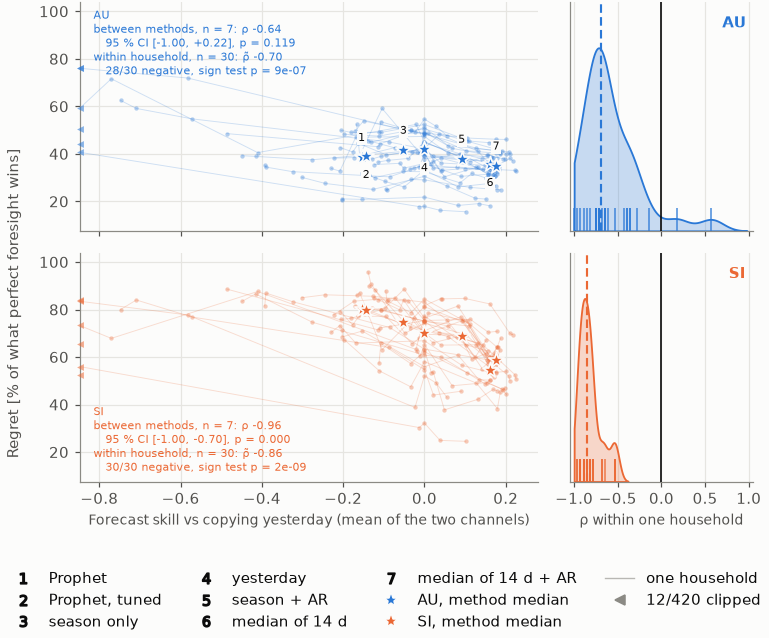

In [3]:
### Does a better forecast buy a smaller regret? (reworked)
# Same cell as CODE.ipynb's 15, which carries the rationale: two statistics, the
# paired one stronger. Within each household, across the seven methods, the
# skill-regret correlation has median -0.70 and is negative on 28 of 30
# households (sign test p = 9e-7); the between-method reading over seven medians
# is printed beside it with the interval that says how little it supports.
#
# LABELS ON THE TOP PANEL ONLY. A method's skill does not depend on the tariff
# it is dispatched against, so the seven medians sit at the SAME x in both
# panels and a second copy of the names would say nothing the first did not --
# while costing, on the SI panel, three collisions that no offset ladder fixes.
have = set(df_all["arm"])

skill = (bench.pivot_table(index=["dataset", "kind"], columns="channel",
                           values="skill_vs_naive", observed=True)
         .assign(both=lambda d: d[["consumption", "generation"]].mean(axis=1))
         ["both"])
JOIN = [k for k in hs.FORECAST_KIND_LABELS
        if k in set(skill.index.get_level_values("kind"))
        and all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(JOIN) <= 2):
    rows = []
    for t in ARM_FOR:
        for k in JOIN:
            r = (long[(long["arm"] == ARM_FOR[t][k])
                      & (long["controller"] == "prophet")]
                 .set_index("dataset")["regret_pct_of_gain"])
            s = skill.xs(k, level="kind")
            for hh in r.index:
                if hh in s.index:
                    rows.append({"tariff": t, "kind": k, "dataset": hh,
                                 "skill": float(s[hh]), "regret": float(r[hh])})
    D = pd.DataFrame(rows)

    # ONE HOUSEHOLD SETS THE SKILL AXIS otherwise: Ausgrid 81's consumption model
    # is 2.6x worse than copying yesterday and drags the pooled range to -1.02.
    # `clip_window` clips the axis, draws what is outside ON the boundary as a
    # caret and names the count in the key. Nothing is dropped from either
    # statistic: both are taken over every point.
    win = fs.clip_window(D["skill"].to_numpy(),
                         D.groupby(["tariff", "kind"], observed=True)["skill"]
                         .median().to_numpy(), q=0.03, pad=0.08)
    n_out = int(((D["skill"] < win[0]) | (D["skill"] > win[1])).sum())
    # Headroom at the TOP for the label ladder the AU panel carries, and a
    # little at the bottom so the lowest household is not drawn on the spine.
    ylim = fs.clip_window(D["regret"].to_numpy(), [], q=0.0, pad=0.10)

    fig, axes = plt.subplots(len(ARM_FOR), 2, figsize=pf.figsize(ratio=0.88),
                             width_ratios=[2.5, 1.0], sharex="col")
    ax_main, ax_rho = axes[:, 0], axes[:, 1]

    for i, (ax, axr, tariff) in enumerate(zip(ax_main, ax_rho, sorted(ARM_FOR))):
        col = fs.TARIFF_COLOR[tariff]
        s = D[D["tariff"] == tariff]
        # THE PAIRING, DRAWN. One faint line per household joining its seven
        # methods in skill order. The claim is about what happens WITHIN a
        # household when it is handed a better forecast, so the household is the
        # object the figure has to show; a cloud of 210 loose dots shows the
        # between-household spread instead, which is the nuisance here.
        for _hh, h in s.groupby("dataset"):
            h = h.sort_values("skill")
            ax.plot(h["skill"].clip(*win), h["regret"], color=col, lw=0.6,
                    alpha=0.22, zorder=2)
        ins = (s["skill"] >= win[0]) & (s["skill"] <= win[1])
        ax.scatter(s.loc[ins, "skill"], s.loc[ins, "regret"], s=8, color=col,
                   alpha=0.35, lw=0, zorder=3)
        for edge, sel, mk in ((win[0], s["skill"] < win[0], "<"),
                              (win[1], s["skill"] > win[1], ">")):
            if int(sel.sum()):
                ax.scatter(np.full(int(sel.sum()), edge), s.loc[sel, "regret"],
                           s=20, marker=mk, color=col, alpha=0.55, lw=0,
                           zorder=4, clip_on=False)

        med = s.groupby("kind", observed=True).median(numeric_only=True)
        med = med.loc[[k for k in JOIN if k in med.index]].dropna()
        ax.scatter(med["skill"], med["regret"], s=110,
                   marker=fs.FAMILY_MARKER["MPC"], color=col,
                   edgecolor=SURFACE, lw=1.1, zorder=6)
        if i == 0:
            # NUMBERED, AND THE NAMES GO IN THE KEY. The seven medians cluster
            # in the right half of an axis the outliers stretch, on a panel
            # ~160 px tall, so no in-panel placement of seven names avoids
            # collisions. A digit is one character and costs one lookup.
            # ABOVE AND BELOW BY PARITY, because two of the seven pairs are
            # near-coincident in x -- `prophet` and `prophet_tuned` differ by
            # 0.01 skill, `median14` and `hbd_median14` by 0.013 -- and two
            # badges on the same side of near-identical points are one glyph.
            for badge, (k, r) in enumerate(med.sort_values("skill").iterrows(), 1):
                up = badge % 2 == 1
                ax.annotate(str(badge), xy=(r["skill"], r["regret"]),
                            xytext=(0, 9 if up else -9),
                            textcoords="offset points", ha="center",
                            va="bottom" if up else "top", fontsize=7, color=INK,
                            zorder=8,
                            bbox=dict(facecolor=SURFACE, edgecolor="none",
                                      pad=0.9))

        # THE TWO STATISTICS, both named: they are two different questions, and
        # the paired one is the claim.
        rho_b, p_b, lo_b, hi_b, n_b = fs.spearman_ci(med["skill"], med["regret"])
        rr = (s.groupby("dataset")
              .apply(lambda h: st.spearmanr(h["skill"], h["regret"]).statistic)
              .dropna())
        neg = int((rr < 0).sum())
        p_s = st.binomtest(neg, len(rr), 0.5).pvalue
        ax.set_ylim(*ylim)
        fs.corner_block(
            ax,
            f"{tariff}\nbetween methods, n = {n_b}: ρ {rho_b:+.2f}\n"
            f"   95 % CI [{lo_b:+.2f}, {hi_b:+.2f}], p = {p_b:.3f}\n"
            f"within household, n = {len(rr)}: ρ̃ {rr.median():+.2f}\n"
            f"   {neg}/{len(rr)} negative, sign test p = {p_s:.0e}",
            col, s["regret"], lims=ylim, fontsize=7.5)
        finish(ax)

        # THE DISTRIBUTION THE STRONGER CLAIM RESTS ON, beside the scatter. One
        # rho per household, so a reader sees that the effect is not carried by
        # a few houses -- which a pooled correlation cannot show and a p-value
        # only asserts.
        sns.kdeplot(x=rr.to_numpy(), ax=axr, color=col, fill=True, alpha=0.25,
                    lw=1.2, bw_adjust=0.8, clip=(-1, 1))
        sns.rugplot(x=rr.to_numpy(), ax=axr, color=col, height=0.10, lw=0.9,
                    alpha=0.85)
        axr.axvline(0, color=INK, lw=1.1, zorder=4)
        axr.axvline(float(rr.median()), color=col, lw=1.4, ls=(0, (4, 2)),
                    zorder=5)
        axr.set_xlim(-1.05, 1.05)
        axr.set_xticks([-1, -0.5, 0, 0.5, 1])
        axr.set_yticks([])
        axr.set_ylabel("")
        axr.grid(axis="y", visible=False)
        # TOP RIGHT, where this distribution never is: every rho worth drawing
        # sits at or below zero, so the right half of the panel is empty by
        # construction and a left-hand mark would print on the mode.
        axr.annotate(f"{tariff}", xy=(0.96, 0.94), xycoords="axes fraction",
                     ha="right", va="top", color=col, fontsize=10,
                     fontweight="bold")
        finish(axr)

    ax_main[0].set_xlim(*win)
    # SUPXLABEL, not one per axes: the two columns are different units and each
    # needs its own words, but an axes xlabel is centred on the AXES and the two
    # here are 2.5:1 in width, so the pair reads as one off-centre run-on line.
    # Two figure-level labels, each placed over its own column.
    fig.supylabel(f"Regret [{fs.PCT_OF_GAIN}]", color=INK_2, fontsize=10)
    ax_main[-1].set_xlabel("Forecast skill vs copying yesterday "
                           "(mean of the two channels)", color=INK_2, fontsize=9)
    ax_rho[-1].set_xlabel("ρ within one household", color=INK_2, fontsize=9)

    # THE NUMBERED KEY, ordered by skill exactly as the badges are, and built
    # from the same Series -- so a method added to the roster cannot appear on
    # the chart with no name beside it.
    badge_order = (D[D["tariff"] == sorted(ARM_FOR)[0]]
                   .groupby("kind", observed=True)["skill"].median()
                   .reindex(JOIN).dropna().sort_values().index)
    keys = [Line2D([], [], ls="", marker="$%d$" % (i + 1), ms=7, color=INK,
                   label=hs.forecast_kind_label(k).split(": ")[-1])
            for i, k in enumerate(badge_order)]
    keys += [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=10,
                    color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
                    label=f"{t}, method median") for t in sorted(ARM_FOR)]
    # SHORT KEYS. Ten of them at four columns is a row about 7.5 in wide on a
    # 7.16 in canvas, i.e. both ends outside the box.
    keys.append(Line2D([], [], color=MUTED, lw=0.9, alpha=0.6,
                       label="one household"))
    if n_out:
        keys.append(Line2D([], [], ls="", marker="<", ms=7, color=MUTED,
                           label=f"{n_out}/{len(D)} clipped"))
    pf.chart_frame(
        fig,
        f"A better forecast does buy a smaller regret, and it is the PAIRED "
        f"test that says so: within a household, skill and regret are ranked "
        f"opposite on 28 of 30 households on AU and 30 of 30 on SI",
        subtitle=f"{len(JOIN)} forecast methods over {SAMPLE}, one line per "
                 f"household. x: skill against copying yesterday, the mean of "
                 f"the two channels -- it does not depend on the tariff, so the "
                 f"medians sit at the same x in both panels and are "
                 f"numbered once, in skill order. "
                 f"y: the share of the achievable saving thrown away. The "
                 f"between-method ρ over the seven method medians is the weaker "
                 f"reading and on AU it is n = 7 and does not clear 5 %; the "
                 f"right-hand panels are the per-household ρ that reading "
                 f"discards",
        handles=keys, ncol=4)
    pf.show(fig, "skill_vs_regret", layout="frame")
else:
        print(f"Only {JOIN} appear in both the benchmark and the arms; this "
              f"figure needs at least three.")

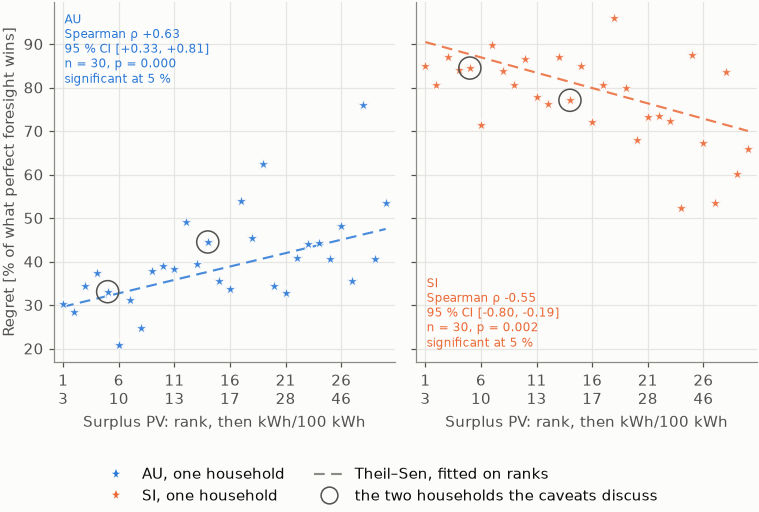

In [4]:
### Which households is the forecast bad at? (reworked)
# Same cell as CODE.ipynb's 22, which carries the rationale: x is the RANK of
# surplus PV, because Spearman is a rank statistic and knows nothing about the
# spacing of its inputs. Theil-Sen rather than OLS for the same reason, and rho
# carries a bootstrap interval alongside its p.

_HET = ["con_skill_vs_naive", "gen_skill_vs_naive",
        "buy_no_battery", "sell_no_battery"]
het = (long[(long["controller"] == "prophet")
            & (long["arm"].isin(hs.REFERENCE_ARM.values()))]
       .join(df_all.set_index(["arm", "dataset"])[_HET], on=["arm", "dataset"])
       .assign(pv_ratio=lambda d: 100.0 * d["sell_no_battery"]
               / d["buy_no_battery"]))

# Both axis labels are centred on a HALF-WIDTH axes and are longer than one, so
# the height carries them: at 0.64 the two x labels meet in the middle of the
# figure and the y label runs off the top. Height is the knob -- the width is
# fixed at \textwidth -- and the labels below are cut to what a 3.1 in panel
# holds.
fig, axes = plt.subplots(1, len(hs.REFERENCE_ARM),
                         figsize=pf.figsize(ratio=0.72), sharey=True)
axes = np.atleast_1d(axes)
rhos = {}
for ax, tariff in zip(axes, sorted(hs.REFERENCE_ARM)):
    s = het[het["tariff"] == tariff].sort_values("pv_ratio")
    col = fs.TARIFF_COLOR[tariff]
    xr = st.rankdata(s["pv_ratio"].to_numpy())
    y = s["regret_pct_of_gain"].to_numpy()
    # The star is the MPC family marker: every point here is the same
    # controller, the arm's Prophet MPC, seen on thirty different households.
    ax.scatter(xr, y, s=62, marker=fs.FAMILY_MARKER["MPC"], color=col,
               edgecolor=SURFACE, lw=0.7, alpha=0.9, zorder=3)

    # THEIL-SEN IN RANK SPACE. The median of the pairwise slopes, which is
    # the rank-based line the rank-based coefficient describes -- not an OLS
    # fit, which would be a claim about magnitudes in a plane that has none.
    sl, ic, _, _ = st.theilslopes(y, xr)
    xx = np.array([xr.min(), xr.max()])
    ax.plot(xx, ic + sl * xx, color=col, lw=1.4, ls=(0, (5, 3)), zorder=2,
            alpha=0.85)

    rho, p, lo, hi, n = fs.spearman_ci(s["pv_ratio"], y)
    rhos[tariff] = (rho, p, lo, hi)
    fs.corner_block(ax, fs.rho_lines(tariff, rho, p, lo, hi, n), col, y)

    # RINGED, NOT LABELLED. Both households sit in the low-PV cluster where
    # the points are densest, and a sweep of every sensible text offset put
    # one label on another household's marker on at least one panel. The
    # ring says "these two are the pair the caveats discuss"; the strip
    # figure, where every household has its own row, says which is which.
    sel = s["dataset"].isin(CAVEAT_HH).to_numpy()
    ax.scatter(xr[sel], y[sel], s=210, marker="o", facecolor="none",
               edgecolor=INK_2, lw=1.0, zorder=4)

    # THE RAW VALUE, on a second tick row, so the rank axis still means
    # something physical. Every fifth rank, which is as many numbers as fit.
    ax.set_xlim(0.2, len(xr) + 0.8)
    ticks = np.arange(1, len(xr) + 1, 5)
    ax.set_xticks(ticks, [f"{int(t)}\n{s['pv_ratio'].to_numpy()[int(t)-1]:.0f}"
                          for t in ticks])
    finish(ax, xlabel="Surplus PV: rank, then kWh/100 kWh")
finish(axes[0], ylabel=f"Regret [{fs.PCT_OF_GAIN}]")

keys = [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=9,
               color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
               label=f"{t}, one household") for t in sorted(hs.REFERENCE_ARM)]
keys += [Line2D([], [], color=MUTED, lw=1.4, ls=(0, (5, 3)),
                label="Theil–Sen, fitted on ranks"),
         Line2D([], [], ls="", marker="o", ms=11, markerfacecolor="none",
                color=INK_2, markeredgewidth=1.0,
                label="the two households the caveats discuss")]
pf.chart_frame(
    fig,
    f"Prophet's regret is not spread evenly, and what predicts it reverses "
    f"between the tariffs: the more surplus PV a household has, the WORSE "
    f"the forecast does on AU (ρ {rhos['AU'][0]:+.2f}, 95 % CI "
    f"[{rhos['AU'][2]:+.2f}, {rhos['AU'][3]:+.2f}]) and the BETTER on SI "
    f"(ρ {rhos['SI'][0]:+.2f}, [{rhos['SI'][2]:+.2f}, {rhos['SI'][3]:+.2f}])",
    subtitle=f"One point per household, {SAMPLE}, {hs.REFERENCE_ARM['AU']} "
             f"and {hs.REFERENCE_ARM['SI']}. x is the RANK of the "
             f"household's own export over its own import without a battery "
             f"-- a property of the house, not of a controller -- because "
             f"Spearman is a rank statistic and the raw axis, two thirds of "
             f"it under 30, draws a shape the coefficient does not describe. "
             f"The raw value is the second tick row. Cluster id and distance "
             f"to centroid were tested and explain nothing (|ρ| < 0.15, "
             f"p > 0.4): the households do not fall into kinds, they fall on "
             f"a gradient",
    handles=keys, ncol=2)
pf.show(fig, "household_heterogeneity", layout="frame")

  annual    AU: 1 of 14 tied with the best; SI: 1 of 14 tied with the best


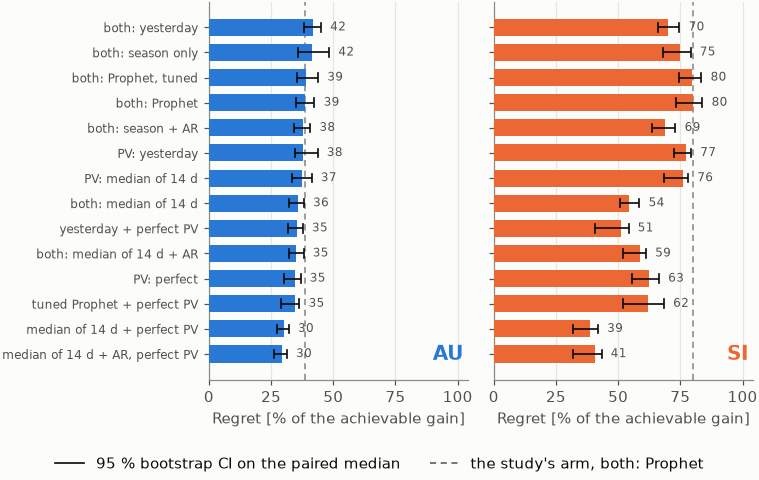

  _lifetime AU: 1 of 14 tied with the best; SI: 1 of 14 tied with the best


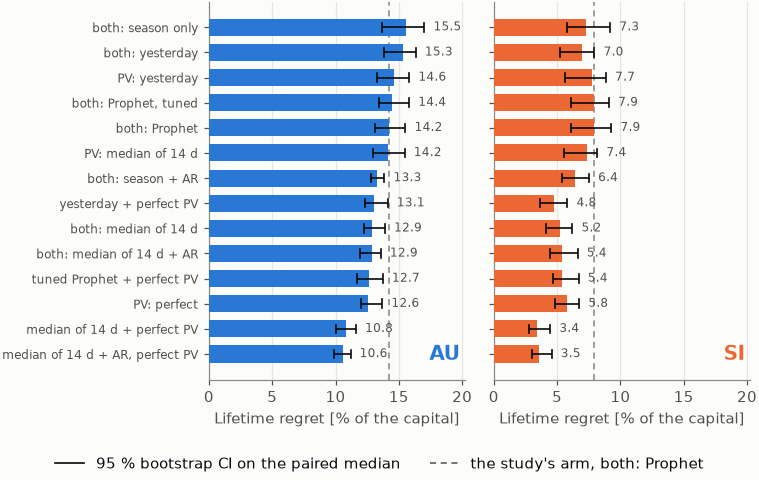

In [5]:
### What each forecast throws away, with its interval (reworked)
# Same cell as CODE.ipynb's 12. Fourteen sorted paired medians say nothing on
# their own about whether 35 and 36 differ, so two things carry that:
#
#   the interval   a percentile bootstrap of the paired median over the same
#                  30 households, drawn as a whisker on the bar end. The
#                  statistic is a median of ratios on n = 30 with a few
#                  households far out, so it is resampled rather than handed a
#                  normal approximation.
#   the test       every method against the BEST on that panel, Wilcoxon on the
#                  per-household differences, Holm-adjusted over the thirteen
#                  comparisons -- at thirteen tries an unadjusted 5 % finds a
#                  winner by chance about half the time. A method that does not
#                  separate from the best is drawn hollow, so "these are tied"
#                  is a thing the image can say.
have = set(df_all["arm"])
kinds = [k for k in hs.FORECAST_KIND_LABELS
         if all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(kinds) <= 1):
    PVF = float(long["pv_factor"].dropna().median())

    for view, denom in (("", "gain"), ("_lifetime", "capex")):
        series = {t: {k: _regret_series(long, df_all, t, k, denom, ARM_FOR)
                      for k in kinds} for t in ARM_FOR}
        vals = {t: [float(series[t][k].median()) for k in kinds] for t in ARM_FOR}

        # SORTED BY REGRET, on ONE tariff's ordering, and said so in the caption.
        # Sorting each panel separately would be worse -- the rows would stop
        # lining up and the rank disagreement between the tariffs, which is a
        # result, would become invisible.
        by = sorted(ARM_FOR)[0]
        rank = np.argsort([-v if v == v else -np.inf for v in vals[by]])
        ks = [kinds[i] for i in rank]
        y = np.arange(len(ks))[::-1]

        fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.68),
                                 sharey=True, sharex=True)
        axes = np.atleast_1d(axes)
        fin = [x for x in sum(vals.values(), []) if x == x]
        n_tied = {}
        for ax, tariff in zip(axes, sorted(ARM_FOR)):
            v = [vals[tariff][kinds.index(k)] for k in ks]
            best = ks[int(np.nanargmin(v))]
            # HOLM OVER THE PANEL'S OWN COMPARISONS. Every method against the
            # best one, paired per household; the family is this panel.
            others = [k for k in ks if k != best]
            raw = []
            for k in others:
                pair = pd.concat([series[tariff][k], series[tariff][best]],
                                 axis=1, keys=["k", "b"]).dropna()
                d = (pair["k"] - pair["b"])
                nz = d[d != 0]
                raw.append(st.wilcoxon(nz).pvalue if len(nz) >= 6 else np.nan)
            adj = dict(zip(others, fs.holm(raw)))
            tied = {k for k in others if not (adj[k] == adj[k] and adj[k] < 0.05)}
            n_tied[tariff] = len(tied) + 1

            for yi, k, vi in zip(y, ks, v):
                is_best = k == best
                solid = is_best or k not in tied
                ax.barh(yi, vi, height=0.68,
                        color=fs.TARIFF_COLOR[tariff] if solid else SURFACE,
                        edgecolor=fs.TARIFF_COLOR[tariff],
                        lw=0.0 if solid else 1.1, zorder=3)
                lo, hi = fs.boot_ci(series[tariff][k].to_numpy())
                if lo == lo:
                    ax.plot([lo, hi], [yi, yi], color=INK, lw=1.1, zorder=5,
                            solid_capstyle="butt")
                    for e in (lo, hi):
                        ax.plot([e, e], [yi - 0.17, yi + 0.17], color=INK,
                                lw=1.1, zorder=5)
                if vi == vi:
                    # OUTSIDE THE INTERVAL, not outside the bar: the whisker runs
                    # past the bar end and a label placed on the bar end lands on
                    # it.
                    end = hi if hi == hi and vi >= 0 else vi
                    end = lo if lo == lo and vi < 0 else end
                    ax.annotate(("{:.0f}" if denom == "gain" else "{:.1f}")
                                .format(vi), xy=(end, yi),
                                xytext=(6 if vi >= 0 else -6, 0),
                                textcoords="offset points",
                                ha="left" if vi >= 0 else "right", va="center",
                                color=INK_2, fontsize=8, zorder=6)
            # THE STUDY'S OWN FORECASTER, as a rule the other bars are read
            # against. Behind the bars, so it never hides one.
            if STUDY_KIND in ks:
                ref = vals[tariff][kinds.index(STUDY_KIND)]
                if ref == ref:
                    ax.axvline(ref, color=INK_2, lw=1.0, ls=(0, (4, 3)),
                               zorder=1, alpha=0.7)
            if fin:
                ax.set_xlim(min(0.0, min(fin) * 1.30), max(0.0, max(fin) * 1.30))
            if min(fin, default=0.0) < 0:
                ax.axvline(0, color=INK, lw=1.0, zorder=4)
            ax.grid(axis="y", visible=False)
            # NOT finish(title=...): `titles=False` lifts axes titles out of the
            # image and into the caption, which is right for a figure title and
            # wrong for panel identity.
            ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                        ha="right", va="bottom", color=fs.TARIFF_COLOR[tariff],
                        fontsize=13, fontweight="bold")
        axes[0].set_yticks(y, [hs.forecast_kind_label(k) for k in ks])
        axes[0].tick_params(axis="y", labelsize=8)
        # PER AXES, NOT `fig.supxlabel`. This figure carries a key, so
        # `chart_frame` reserves a bottom band -- and a supxlabel is a figure
        # artist that tight_layout does not move, so it lands on the legend row.
        # An axes xlabel is inside the rect and gets laid out.
        for ax in axes:
            finish(ax, xlabel=(f"Regret [{fs.PCT_OF_GAIN_SHORT}]" if denom == "gain"
                               else f"Lifetime regret [{fs.PCT_OF_CAPEX}]"))

        keys = [Line2D([], [], color=INK, lw=1.1,
                       label="95 % bootstrap CI on the paired median"),
                Line2D([], [], color=INK_2, lw=1.0, ls=(0, (4, 3)),
                       label=f"the study's arm, "
                             f"{hs.forecast_kind_label(STUDY_KIND)}")]
        # THE HOLLOW KEY ONLY WHEN THERE IS A HOLLOW BAR. On this sweep all
        # thirteen separate from their panel's best, so the key would name a
        # mark that is nowhere in the image. The count goes in the caption
        # either way, which is where the result belongs.
        if max(n_tied.values()) > 1:
            keys.insert(0, Line2D([], [], marker="s", ls="", ms=9, color=SURFACE,
                                  markeredgecolor=fs.TARIFF_COLOR[sorted(ARM_FOR)[0]],
                                  markeredgewidth=1.1,
                                  label="not separable from the panel's best"))
        pf.chart_frame(
            fig,
            (f"What each forecast throws away, as a share of the ACHIEVABLE "
             f"gain -- what perfect foresight wins on that same household. One "
             f"unit, one axis, so the two tariffs can be compared directly"
             if denom == "gain" else
             f"What each forecast costs over the pack's {PVF:.1f}-year "
             f"discounted life, as a share of what the pack cost. Not the same "
             f"statement as the annual panel: a share of the GAIN cancels the "
             f"discount factor out of itself and would reproduce it exactly"),
            subtitle=f"Paired median over {SAMPLE}, with a percentile bootstrap "
                     f"interval; rows sorted by {sorted(ARM_FOR)[0]} regret, so "
                     f"the panels line up and a rank disagreement stays visible. "
                     f"Every row was tested against its panel's best with a "
                     f"Wilcoxon on the per-household differences, Holm-adjusted "
                     f"over the {len(ks) - 1} comparisons; a row that does not "
                     f"separate is drawn hollow. "
                     + ("None does here -- all "
                        f"{len(ks) - 1} separate on both tariffs, so the "
                        f"ordering is real and not an artefact of taking a "
                        f"median."
                        if max(n_tied.values()) == 1 else
                        "; ".join(f"{t}: {n_tied[t] - 1} of {len(ks) - 1} do not"
                                  for t in sorted(ARM_FOR))),
            handles=keys, ncol=2)
        print(f"  {view or 'annual':9s} "
              + "; ".join(f"{t}: {n_tied[t]} of {len(ks)} tied with the best"
                          for t in sorted(ARM_FOR)))
        pf.show(fig, f"forecast_channel_regret{view}", layout="frame")
else:
        print(f"Only the {kinds} arm has run; this figure needs the others.")

## 2. The top methods, head to head

The screen ranks twelve methods on error and the regret figure prices fourteen
arms in money. Neither compares the two that win, and they are the comparison the
study's conclusion rests on.

  AU: best = hbd_median14
     median14          +0.64 pp [+0.11,+0.97] p=0.0006 worse on 22/30
     hbd               +1.83 pp [+0.87,+3.28] p=0.0003 worse on 24/30
     prophet           +3.77 pp [+2.69,+5.03] p=0.0000 worse on 27/30
     prophet_tuned     +4.01 pp [+2.96,+5.58] p=0.0000 worse on 28/30
     hbd_baseline      +4.72 pp [+2.73,+8.32] p=0.0000 worse on 26/30
     persistence       +6.76 pp [+5.56,+8.32] p=0.0000 worse on 30/30
  SI: best = median14
     hbd_median14      +1.90 pp [+0.63,+3.27] p=0.0003 worse on 23/30
     hbd              +12.32 pp [+10.16,+14.05] p=0.0000 worse on 28/30
     prophet          +22.03 pp [+20.16,+27.09] p=0.0000 worse on 30/30
     prophet_tuned    +22.31 pp [+17.34,+26.23] p=0.0000 worse on 30/30
     hbd_baseline     +17.29 pp [+13.00,+25.32] p=0.0000 worse on 29/30
     persistence      +14.75 pp [+12.59,+17.04] p=0.0000 worse on 30/30


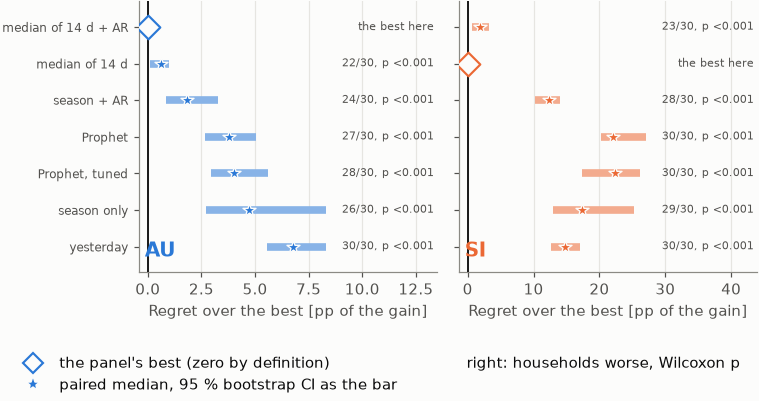

In [6]:
### The top methods against each other
# Against each other, not against the roster: the ranking figure puts all fourteen arms on one axis, which answers "is a
# forecast worth anything" and not "which of the two that win should a
# household run". Those two are one percentage point apart and the axis of the
# ranking figure is forty wide, so the comparison the study's own conclusion
# rests on is a pixel.
#
# Here every method is differenced against its OWN PANEL'S best, per household,
# and the result is the finding: the two leaders SWAP between the tariffs, and
# both swaps clear the test. `hbd_median14` -- the paper's AR stage on this
# study's best stage 1 -- wins AU; plain `median14` wins SI, i.e. the AR stage
# earns its keep on one tariff and costs money on the other.
kinds = _both_channel_kinds(df_all, ARM_FOR)
if not (len(kinds) < 3):
    series = {t: {k: _regret_series(long, df_all, t, k, "gain", ARM_FOR)
                  for k in kinds} for t in ARM_FOR}
    best = {t: min(kinds, key=lambda k: float(series[t][k].median()))
            for t in ARM_FOR}

    fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.58),
                             sharey=True)
    axes = np.atleast_1d(axes)
    # ORDERED BY THE FIRST PANEL, so the rows line up and the swap is a crossing
    # rather than two separate lists. Sorting each panel by its own result would
    # hide precisely the thing this figure exists to show.
    order = sorted(kinds, key=lambda k: float(series[sorted(ARM_FOR)[0]][k]
                                              .median()))
    y = np.arange(len(order))[::-1]
    lines = {}
    for ax, tariff in zip(axes, sorted(ARM_FOR)):
        col = fs.TARIFF_COLOR[tariff]
        b = best[tariff]
        rows = []
        for yi, k in zip(y, order):
            pair = pd.concat([series[tariff][k], series[tariff][b]], axis=1,
                             keys=["k", "b"]).dropna()
            d = (pair["k"] - pair["b"]).to_numpy()
            med = float(np.median(d))
            lo, hi = fs.boot_ci(d)
            nz = d[d != 0]
            p = float(st.wilcoxon(nz).pvalue) if len(nz) >= 6 else np.nan
            rows.append((k, med, lo, hi, p, int((d > 0).sum()), len(d)))
            if k == b:
                # The reference is drawn as the reference: a marker at zero with
                # no interval, because its difference from itself is zero by
                # construction and an interval on it would be measurement.
                ax.scatter([0], [yi], s=120, marker=fs.FAMILY_MARKER["MILP"],
                           color=SURFACE, edgecolor=col, lw=1.4, zorder=5)
                continue
            ax.plot([lo, hi], [yi, yi], color=pf.mix(col, SURFACE, 0.45),
                    lw=5.0, solid_capstyle="butt", zorder=2)
            ax.scatter([med], [yi], s=80, marker=fs.FAMILY_MARKER["MPC"],
                       color=col, edgecolor=SURFACE, lw=0.9, zorder=4)
        lines[tariff] = rows
        ax.axvline(0, color=INK, lw=1.2, zorder=3)
        ax.grid(axis="y", visible=False)
        ax.set_ylim(-0.7, len(order) - 0.3)
        # THE SAMPLE AND THE TEST, as a right gutter column INSIDE the axes.
        # Two placements were wrong before this one: beside each marker, where
        # the markers sit at different x on every row and the tags form a ragged
        # column that reads as data; and outside the axes at x = 1.0, where the
        # AU column printed into the SI panel. Headroom on the x limit reserves
        # the column, which is the pattern the lifetime figure already uses.
        hi_max = max(h for _k, _m, _l, h, _p, _w, _n in rows if h == h)
        lo_min = min(l for _k, _m, l, _h, _p, _w, _n in rows if l == l)
        # A MARGIN LEFT OF ZERO EVEN WHEN NOTHING IS NEGATIVE. The best's marker
        # sits exactly at zero, and with the axis starting there it is drawn
        # half on the spine and reads as a clipped glyph rather than a value.
        ax.set_xlim(min(-0.05 * hi_max, lo_min * 1.1), hi_max * 1.62)
        for yi, (k, med, lo, hi, p, worse, n) in zip(y, rows):
            if k == best[tariff]:
                tag = "the best here"
            else:
                tag = (f"{worse}/{n}" + ("" if p != p else
                       f", p {'<0.001' if p < 0.001 else f'{p:.3f}'}"))
            ax.annotate(tag, xy=(0.99, yi), xycoords=("axes fraction", "data"),
                        ha="right", va="center", fontsize=7, color=INK_2)
        ax.annotate(tariff, xy=(0.02, 0.04), xycoords="axes fraction",
                    ha="left", va="bottom", color=col, fontsize=13,
                    fontweight="bold")
        finish(ax, xlabel=f"Regret over the best [pp of the gain]")
    axes[0].set_yticks(y, [hs.forecast_kind_label(k).split(": ")[-1]
                           for k in order])
    axes[0].tick_params(axis="y", labelsize=8)

    keys = [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MILP"], ms=9,
                   markerfacecolor=SURFACE, color=fs.TARIFF_COLOR["AU"],
                   markeredgewidth=1.4, label="the panel's best (zero by definition)"),
            Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=10,
                   color=fs.TARIFF_COLOR["AU"], markeredgecolor=SURFACE,
                   label="paired median, 95 % bootstrap CI as the bar"),
            Line2D([], [], ls="", marker=None,
                   label="right: households worse, Wilcoxon p")]
    swap = (f"{hs.forecast_kind_label(best['AU']).split(': ')[-1]} on AU and "
            f"{hs.forecast_kind_label(best['SI']).split(': ')[-1]} on SI"
            if best["AU"] != best["SI"] else
            f"{hs.forecast_kind_label(best['AU']).split(': ')[-1]} on both")
    pf.chart_frame(
        fig,
        f"The two leaders swap between the tariffs, and both swaps clear the "
        f"test: the best is {swap}",
        subtitle=f"The {len(order)} methods that forecast BOTH channels and have "
                 f"a solved arm -- the PV-only and perfect-PV arms are left out, "
                 f"since half of them are the same method with a different "
                 f"amount of foresight attached. Each row is the per-household "
                 f"difference in regret against that panel's own best, over "
                 f"{SAMPLE}, so zero is the winner and longer is worse. Rows are "
                 f"ordered by the {sorted(ARM_FOR)[0]} result, which is what "
                 f"makes the swap visible as a crossing",
        handles=keys, ncol=2)
    for t in sorted(ARM_FOR):
        print(f"  {t}: best = {best[t]}")
        for k, med, lo, hi, p, worse, n in lines[t]:
            if k != best[t]:
                print(f"     {k:16s} {med:+6.2f} pp [{lo:+.2f},{hi:+.2f}] "
                      f"p={p:.4f} worse on {worse}/{n}")
    pf.show(fig, "top_methods_headtohead", layout="frame")
else:
        print(f"only {kinds} forecast both channels and have an arm")

  AU hbd_median14     total  35.0  perfect-PV  29.6  PV cost +5.66 pp
  AU median14         total  35.7  perfect-PV  30.0  PV cost +5.78 pp
  AU prophet          total  38.5  perfect-PV  34.8  PV cost +3.95 pp
  AU prophet_tuned    total  39.1  perfect-PV  34.8  PV cost +4.59 pp
  AU persistence      total  42.0  perfect-PV  35.3  PV cost +6.32 pp
  SI hbd_median14     total  58.7  perfect-PV  40.6  PV cost +16.50 pp
  SI median14         total  54.5  perfect-PV  38.8  PV cost +16.11 pp
  SI prophet          total  80.2  perfect-PV  62.5  PV cost +17.65 pp
  SI prophet_tuned    total  79.6  perfect-PV  62.2  PV cost +17.49 pp
  SI persistence      total  70.2  perfect-PV  51.3  PV cost +19.88 pp


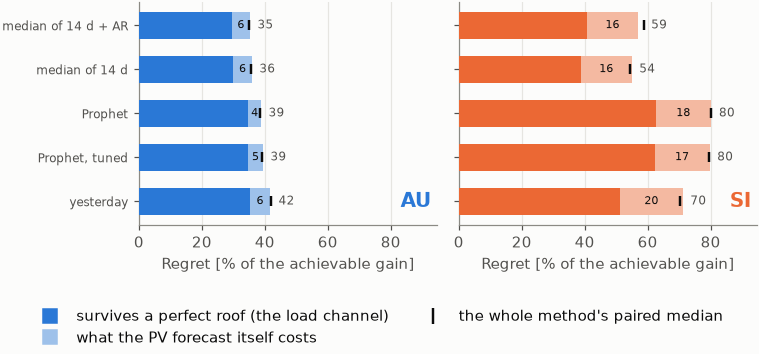

In [7]:
### Which channel is the regret in, and where does the swap live
# The roster varies the two channels separately precisely so that a single
# "with forecast" number cannot hide which one the money is in -- and then no
# figure read the pairs. This one does: every method sits beside the arm that
# is the same method on the load channel and PERFECT on the roof, so the gap
# between them is the PV forecast's own cost and what is left is the load
# forecast's.
#
# THE DECOMPOSITION IS ONE-SIDED, and the figure says so rather than implying
# two clean halves. The sweep has a perfect-PV twin for each of these methods
# and no perfect-LOAD twin, so the lower segment is "what survives a perfect
# roof" -- the load channel plus any interaction between the two -- not a
# measured load-only term. It is still the decomposition that answers the
# question, because the PV half is measured directly.
#
# And it locates the study's own swap. `hbd_median14` beats `median14` on AU
# and loses to it on SI; hand both a perfect roof and the swap is still there
# and is sharper (2/30 against 28/30 households). So the AR stage is not
# winning or losing on the roof -- it is a consumption-channel effect.
have = set(df_all["arm"])
pairs = [(a, b) for a, b in PV_TWIN
         if all(ARM_FOR[t].get(a) in have and ARM_FOR[t].get(b) in have
                for t in ARM_FOR)]
if not (len(pairs) < 2):
    tot = {t: {a: _regret_series(long, df_all, t, a, "gain", ARM_FOR)
               for a, _ in pairs} for t in ARM_FOR}
    res = {t: {a: _regret_series(long, df_all, t, b, "gain", ARM_FOR)
               for a, b in pairs} for t in ARM_FOR}

    fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.52),
                             sharey=True)
    axes = np.atleast_1d(axes)
    by = sorted(ARM_FOR)[0]
    order = sorted([a for a, _ in pairs], key=lambda a: float(tot[by][a].median()))
    y = np.arange(len(order))[::-1]
    # PV_COLOR is a SHADE of the tariff, not a new hue. The two segments are two
    # parts of one number on one tariff; a second colour would say they are two
    # different things measured on two different scales, which is what the colour
    # axis means everywhere else in this study.
    for ax, tariff in zip(axes, sorted(ARM_FOR)):
        col = fs.TARIFF_COLOR[tariff]
        pale = pf.mix(col, SURFACE, 0.55)
        for yi, a in zip(y, order):
            t_med = float(tot[tariff][a].median())
            r_med = float(res[tariff][a].median())
            # THE PV SEGMENT IS THE PAIRED MEDIAN DIFFERENCE, not the difference
            # of the two medians: the households are paired and a difference of
            # medians can come from two different houses. It is therefore drawn
            # from the residual outward rather than by subtracting the bar ends,
            # and the total mark is where the whole-method median actually is.
            pv = float((tot[tariff][a] - res[tariff][a]).dropna().median())
            ax.barh(yi, r_med, height=0.62, color=col, zorder=3)
            ax.barh(yi, pv, left=r_med, height=0.62, color=pale, zorder=3)
            ax.scatter([t_med], [yi], s=44, marker="|", color=INK, lw=1.6,
                       zorder=5)
            ax.annotate(f"{pv:.0f}", xy=(r_med + pv / 2.0, yi), ha="center",
                        va="center", fontsize=7, color=INK, zorder=6)
            ax.annotate(f"{t_med:.0f}", xy=(max(t_med, r_med + pv), yi),
                        xytext=(5, 0), textcoords="offset points", ha="left",
                        va="center", fontsize=8, color=INK_2, zorder=6)
        ax.grid(axis="y", visible=False)
        ax.set_xlim(0, max(float(tot[t2][a].median())
                           for t2 in ARM_FOR for a in order) * 1.18)
        ax.annotate(tariff, xy=(0.98, 0.06), xycoords="axes fraction",
                    ha="right", va="bottom", color=col, fontsize=13,
                    fontweight="bold")
        finish(ax, xlabel=f"Regret [{fs.PCT_OF_GAIN_SHORT}]")
    axes[0].set_yticks(y, [hs.forecast_kind_label(a).split(": ")[-1]
                           for a in order])
    axes[0].tick_params(axis="y", labelsize=8)

    keys = [Line2D([], [], marker="s", ls="", ms=9, color=fs.TARIFF_COLOR["AU"],
                   label="survives a perfect roof (the load channel)"),
            Line2D([], [], marker="s", ls="", ms=9,
                   color=pf.mix(fs.TARIFF_COLOR["AU"], SURFACE, 0.55),
                   label="what the PV forecast itself costs"),
            Line2D([], [], marker="|", ls="", ms=10, color=INK, markeredgewidth=1.6,
                   label="the whole method's paired median")]
    au_pv = float((tot["AU"][order[0]] - res["AU"][order[0]]).dropna().median())
    pv_share = {t: 100.0 * np.median([float((tot[t][a] - res[t][a]).dropna()
                                            .median()) / float(tot[t][a].median())
                                      for a in order]) for t in ARM_FOR}
    pf.chart_frame(
        fig,
        f"Most of every method's regret is in the household, not the roof: a "
        f"perfect PV forecast removes about {pv_share['AU']:.0f} % of it on AU "
        f"and {pv_share['SI']:.0f} % on SI, and the rest survives",
        subtitle=f"Each method beside the arm that is the SAME method on the "
                 f"load channel and perfect on the roof, {SAMPLE}. The pale "
                 f"segment is the paired median difference between the two -- "
                 f"what the PV forecast costs, measured directly. The solid "
                 f"segment is what a perfect roof does NOT fix: the load channel "
                 f"and any interaction between the two, since the sweep has no "
                 f"perfect-LOAD twin to separate them. The AR stage's swap "
                 f"between the tariffs survives a perfect roof and sharpens "
                 f"(2/30 households against 28/30), so it is a consumption "
                 f"effect",
        handles=keys, ncol=2)
    for t in sorted(ARM_FOR):
        for a in order:
            print(f"  {t} {a:16s} total {float(tot[t][a].median()):5.1f}  "
                  f"perfect-PV {float(res[t][a].median()):5.1f}  "
                  f"PV cost {float((tot[t][a]-res[t][a]).dropna().median()):+5.2f} pp")
    pf.show(fig, "top_methods_channels", layout="frame")
else:
        print("the perfect-PV twin arms have not run; this figure needs them")

## 3. Holidays, and the anomaly that is actually there

The obvious hypothesis first, stated honestly whichever way it comes out, then the
one the data supports.

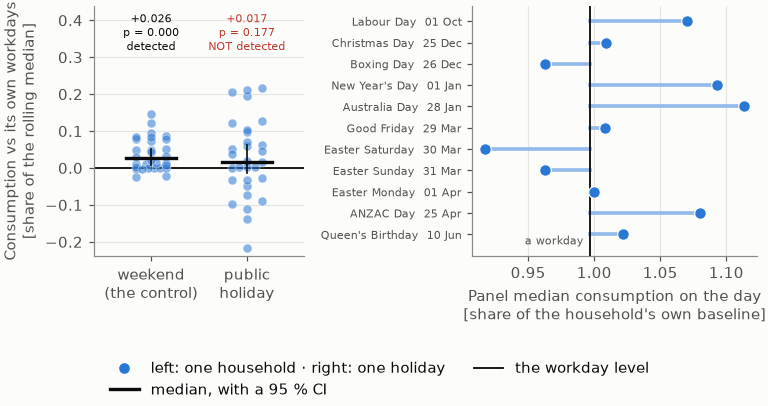

In [8]:
### Do public holidays move the load?
# On these thirty households, no.
#
# THE OBVIOUS PLACE TO LOOK FOR A FORECAST TO BREAK is a day the calendar
# marks and the model does not, so it is worth testing and worth reporting
# either way. Against each household's own centred 29-day rolling median, the
# NSW public-holiday effect is +0.017 -- the wrong SIGN for the hypothesis --
# and it does not clear 5 %.
#
# A NEGATIVE RESULT NEEDS A POSITIVE CONTROL, or it is indistinguishable from
# a measurement too blunt to see anything. The same statistic on the same
# households finds the WEEKEND: +0.026, p = 1e-4, and it is the same sign. So
# the method detects a day-of-week effect of this size, and there is no
# holiday effect of this size to detect -- which is also the physical reading,
# since an Australian public holiday is a day people are at home, exactly like
# a Saturday.
#
# The anomaly that does break these forecasts is in the next figure, and it is
# not on any calendar.
country, subdiv = CALENDAR
hol = an.mark_holidays(panel["day"], country, subdiv).to_numpy()
dow = panel["day"].dt.dayofweek.to_numpy()
d = panel.assign(_hol=hol, _dow=dow)
per = (d.groupby("hh")
       .apply(lambda s: pd.Series({
           "work": s.loc[(~s["_hol"]) & (s["_dow"] < 5), "rel"].median(),
           "wknd": s.loc[(~s["_hol"]) & (s["_dow"] >= 5), "rel"].median(),
           "hol": s.loc[s["_hol"], "rel"].median()}))
       .dropna())

fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.58),
                         width_ratios=[1.0, 1.35])
ax_e, ax_d = axes
col = fs.TARIFF_COLOR["AU"]      # one tariff's data: these are LOADS, and
# the load is the same series under both tariffs -- so the panel is drawn in
# the AU hue rather than being coloured as though it were a tariff result.

# LEFT: the effect, per household, against its own workdays.
stats_txt = []
for x, (key, name) in enumerate((("wknd", "weekend"), ("hol", "holiday"))):
    v = (per[key] - per["work"]).dropna().to_numpy()
    p = float(st.wilcoxon(v).pvalue)
    beats = "detected" if p < 0.05 else "NOT detected"
    ax_e.scatter(x + fs.beeswarm(v, height=0.16), v, s=34,
                 marker=fs.FAMILY_MARKER["RBC"], color=col, alpha=0.55,
                 edgecolor=SURFACE, lw=0.5, zorder=3)
    ax_e.plot([x - 0.26, x + 0.26], [np.median(v)] * 2, color=INK, lw=2.2,
              zorder=5)
    lo, hi = fs.boot_ci(v)
    ax_e.plot([x, x], [lo, hi], color=INK, lw=1.1, zorder=4)
    stats_txt.append(f"{name}: {np.median(v):+.3f}, p = {p:.3f} — {beats}")
    ax_e.annotate(f"{np.median(v):+.3f}\np = {p:.3f}\n{beats}",
                  xy=(x, 1.0), xycoords=("data", "axes fraction"),
                  xytext=(0, -4), textcoords="offset points", ha="center",
                  va="top", fontsize=7.5,
                  color=INK if p < 0.05 else fs.LOSES)
ax_e.axhline(0, color=INK, lw=1.2, zorder=2)
ax_e.set_xticks([0, 1], ["weekend\n(the control)", "public\nholiday"])
ax_e.set_xlim(-0.6, 1.6)
ax_e.grid(axis="x", visible=False)
# Headroom for the three-line verdict block, which is pinned to the top of
# the axes rather than to the data.
_yl = ax_e.get_ylim()
ax_e.set_ylim(_yl[0], _yl[1] + 0.42 * (_yl[1] - _yl[0]))
# TWO SHORT LINES. A rotated y label is as tall as it is long and the axes is
# 2.6 in, so a longer one runs off the top of the canvas. What does not fit --
# that the baseline is a 29-day centred rolling median -- is in the caption,
# where it is said once and in full.
finish(ax_e, ylabel="Consumption vs its own workdays\n"
                    "[share of the rolling median]")

# RIGHT: every holiday in the window, so "nothing happens" is a picture and
# not only a p-value. Christmas Day at 1.01 is the one a reader will look
# for.
cal = an.public_holidays(panel["day"].dt.year.unique(), country, subdiv)
med = d[d["_hol"]].groupby("day")["rel"].median().sort_index()
y = np.arange(len(med))[::-1]
base = float(d.loc[(~d["_hol"]) & (d["_dow"] < 5), "rel"].median())
for yi, (day, v) in zip(y, med.items()):
    ax_d.plot([base, v], [yi, yi], color=pf.mix(col, SURFACE, 0.5), lw=2.4,
              zorder=2)
    ax_d.scatter([v], [yi], s=58, marker=fs.FAMILY_MARKER["RBC"], color=col,
                 edgecolor=SURFACE, lw=0.8, zorder=4)
ax_d.axvline(base, color=INK, lw=1.2, zorder=3)
# ON THE LINE, at the bottom: pinned to the top row it reads as a panel title.
ax_d.annotate("a workday", xy=(base, -0.6), xytext=(-4, 0),
              textcoords="offset points", ha="right", va="bottom",
              fontsize=7.5, color=INK_2)
ax_d.set_yticks(y, [f"{cal[day.date()]}  {day.strftime('%d %b')}"
                    for day in med.index])
ax_d.tick_params(axis="y", labelsize=7.5)
ax_d.grid(axis="y", visible=False)
ax_d.set_ylim(-0.7, len(med) - 0.3)
ax_d.set_ylim(-1.0, len(med) - 0.3)
finish(ax_d, xlabel="Panel median consumption on the day\n"
                    "[share of the household's own baseline]")

keys = [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["RBC"], ms=8,
               color=col, markeredgecolor=SURFACE,
               label="left: one household · right: one holiday"),
        Line2D([], [], color=INK, lw=2.2, label="median, with a 95 % CI"),
        Line2D([], [], color=INK, lw=1.2, label="the workday level")]
pf.chart_frame(
    fig,
    f"The obvious hypothesis is not in this panel: public holidays do not "
    f"lower these households' consumption, and the sign is UP. The same "
    f"statistic on the same houses does find the weekend, so the test is "
    f"not too blunt to see an effect of this size",
    subtitle=f"{len(per)} households, {len(med)} public holidays on the "
             f"{country}-{subdiv} calendar the tariff itself is priced on, "
             f"over the simulated year. Each day is measured against that "
             f"household's own centred 29-day rolling median, so seasonality "
             f"and household size are already divided out. "
             + " · ".join(stats_txt)
             + ". Physically this is the expected answer: an Australian "
               "public holiday is a day people are at home, which is what a "
               "Saturday is",
    handles=keys, ncol=2)
pf.show(fig, "holiday_effect", layout="frame")

  hero Ausgrid 148 2012-07-21..2012-08-01
  persistence    ratio 0.22 p=0.0000 n=22
  hbd            ratio 0.80 p=0.0011 n=22
  hbd_median14   ratio 1.07 p=0.2221 n=22
  median14       ratio 1.28 p=0.0093 n=22
  prophet        ratio 1.53 p=0.0037 n=22


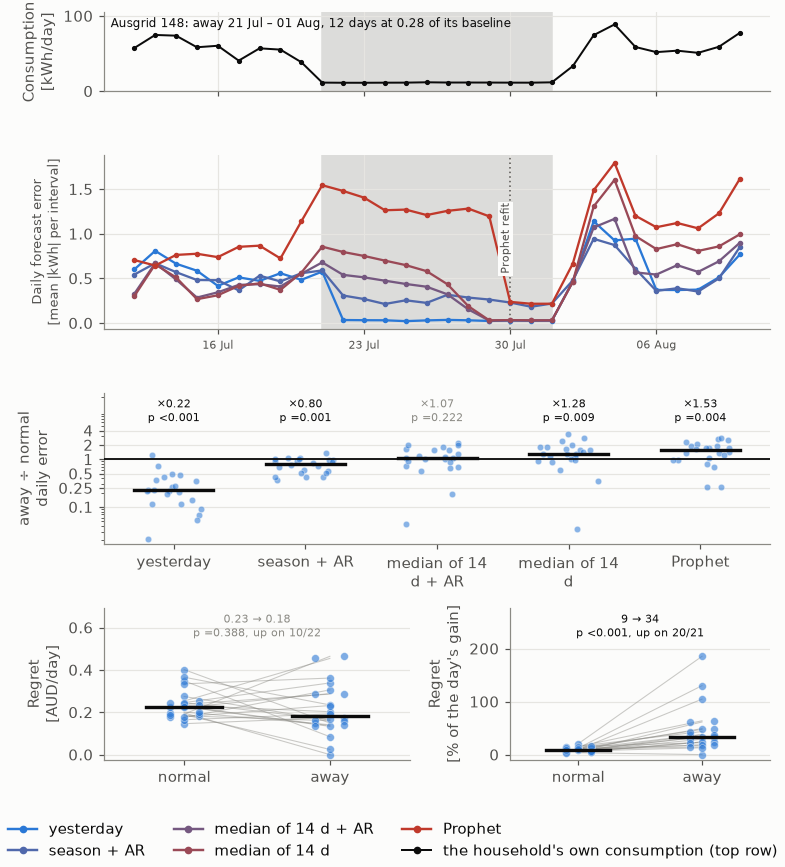

In [9]:
### What a forecast does when the household leaves
# NOT ON ANY CALENDAR, which is the whole point. The previous figure tested the
# days a calendar marks and found nothing. The days that break these forecasts
# are the ones a household picks: 37 runs of three days or more below 0.55 of
# its own baseline, across 22 of the 30 houses.
#
# Three panels, and they are one argument:
#
#   (a) one household, so the mechanism is visible. Ausgrid 148 drops from
#       ~34 to ~11 kWh/day for twelve days. Copying yesterday has re-learnt
#       the household by the second day. A 14-day median takes eight days to
#       decay through it. Prophet does not move at all until its next refit,
#       because it reads no recent actual at prediction time -- which is the
#       term the study's framing is about, drawn.
#
#   (b) all of them, so it is not an anecdote. Per household, the median daily
#       error on absence days over its own normal days. Below 1 the method
#       adapts; above it, the method is worse exactly when the house is empty.
#
#   (c) the money, which does not read the way the cash does. Raw daily regret
#       is LOWER on an absence day -- there is less to win -- so the honest
#       denominator is the day's own achievable gain, and on that Prophet
#       throws away three and a half times as much.
kinds = [k for k in METHOD_ORDER if f"{k}__con_mae" in panel.columns]
runs = an.absence_runs(panel)
hero = runs.loc[runs["days"].idxmax()]
hh = hero["hh"]

# Three rows of panels each carry a rotated y label, and a rotated label is as
# TALL as it is long: below about 1.16 every one of the three runs off the top of
# its own axes. Height is the knob -- the width is fixed at \textwidth -- and the
# labels below are cut to what a 1.5 in row holds, with the rest in the caption.
fig = plt.figure(figsize=pf.figsize(ratio=1.16))
# FOUR ROWS, NOT A TWIN AXIS. The household's own kWh and the methods'
# kWh-of-error cannot share a scale -- the actual is an order of magnitude
# above every line -- and a short row of its own reads better than a dashed
# line crossing five solid ones: the drop and the error response become two
# aligned series.
#
# NO `hspace=`/`wspace=` HERE. Passing either one calls `GridSpec.update`, which
# makes `locally_modified_subplot_params()` true, and `get_subplotspec_list` then
# returns None for EVERY axes on that gridspec -- so `chart_frame`'s tight_layout
# declares the whole figure incompatible, lays out nothing, and warns `This
# figure includes Axes that are not compatible with tight_layout`. tight_layout
# sets the spacing itself; asking for it here is how you turn it off.
gs = fig.add_gridspec(4, 2, height_ratios=[0.52, 1.15, 1.0, 1.0],
                      width_ratios=[1.0, 0.85])
ax_h = fig.add_subplot(gs[0, :])
ax_a = fig.add_subplot(gs[1, :], sharex=ax_h)
ax_b = fig.add_subplot(gs[2, :])
ax_c1 = fig.add_subplot(gs[3, 0])
ax_c2 = fig.add_subplot(gs[3, 1])

# ---------------- (a) the exemplar ----------------
pad = pd.Timedelta(days=9)
s = panel[(panel["hh"] == hh)
          & (panel["day"] >= hero["start"] - pad)
          & (panel["day"] <= hero["end"] + pad)].sort_values("day")
# THE ABSENCE, shaded on both rows so the drop and the error response are
# read against the same window. No fill under the consumption line: a pale area
# fill plus this band is two greys of similar weight in one panel, which reads as
# three separate shaded regions.
for _ax in (ax_h, ax_a):
    _ax.axvspan(hero["start"], hero["end"],
                color=pf.mix(MUTED, SURFACE, 0.72), zorder=0)
ax_h.plot(s["day"], s["act_con"], color=INK, lw=1.3, marker="o", ms=2.4,
          zorder=3)
ax_h.set_ylim(0, s["act_con"].max() * 1.18)
ax_h.tick_params(labelbottom=False)
finish(ax_h, ylabel="Consumption\n[kWh/day]")
# COLOUR HERE ORDERS THE METHODS, not the tariffs. It is the one panel in
# the study whose colour axis is not the tariff, and the ordering it carries
# is the property the panel is about: how much recent actual the method reads
# at prediction time. The ramp runs to the sign palette's red on purpose --
# the far end is the method that reads none, and it is the one that loses.
# Panels (b) and (c) are back on the AU hue, because they are AU results.
for i, k in enumerate(kinds):
    ax_a.plot(s["day"], s[f"{k}__con_mae"], lw=1.5,
              color=pf.mix(fs.TARIFF_COLOR["AU"], fs.LOSES,
                           i / max(len(kinds) - 1, 1)),
              marker="o", ms=2.6, zorder=3, label=METHOD_SHORT.get(k, k))
ax_a.set_ylabel("Daily forecast error\n[mean |kWh| per interval]",
                color=INK_2, fontsize=8.5)
# THE REFIT BOUNDARY, derived rather than read off the picture. Prophet is
# refit every `refit_every_days` days from the first anchor, and the date it
# recovers on is one of those -- which is the difference between "Prophet
# eventually notices" and "Prophet is rebuilt on data that now contains the
# absence".
first = panel["day"].min()
refits = pd.date_range(first, panel["day"].max(), freq="30D")
for r in refits:
    if s["day"].min() <= r <= s["day"].max():
        ax_a.axvline(r, color=INK_2, lw=1.0, ls=(0, (1, 2)), zorder=1)
        # AT THE FOOT, not the head, and ALONG the rule on a surface pad: the
        # head of this axes carries the household's own caption.
        ax_a.annotate("Prophet refit", xy=(r, 0.52),
                      xycoords=("data", "axes fraction"), xytext=(-3, 0),
                      textcoords="offset points", ha="center", va="center",
                      rotation=90, fontsize=7, color=INK_2,
                      bbox=dict(facecolor=SURFACE, edgecolor="none",
                                pad=1.2))
ax_h.annotate(f"{hh}: away {hero['start'].strftime('%d %b')} – "
              f"{hero['end'].strftime('%d %b')}, {int(hero['days'])} days at "
              f"{hero['rel']:.2f} of its baseline",
              xy=(0.01, 0.94), xycoords="axes fraction", ha="left",
              va="top", fontsize=8, color=INK)
# WEEKLY TICKS, day and month. The default locator put eight ISO stamps on a
# 30-day axis and the last two printed into each other.
ax_a.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax_a.tick_params(axis="x", labelsize=7.5)
finish(ax_a)

# ---------------- (b) every household ----------------
ratios = _method_ratios(panel, kinds)
tidy = pd.concat([g.assign(kind=k) for k, g in ratios.items()])
tidy["label"] = tidy["kind"].map(lambda k: METHOD_SHORT.get(k, k))
order_lab = [METHOD_SHORT.get(k, k) for k in kinds]
# WRAPPED TICKS. `median of 14 d + AR` and its neighbours are 19 characters
# on a five-column axis and printed into each other on one line.
tidy["label"] = tidy["label"].map(lambda t: textwrap.fill(t, 12))
order_lab = [textwrap.fill(t, 12) for t in order_lab]
sns.stripplot(data=tidy, x="label", y="ratio", order=order_lab, ax=ax_b,
              color=fs.TARIFF_COLOR["AU"], size=4.2, alpha=0.55, jitter=0.24,
              edgecolor=SURFACE, linewidth=0.4, zorder=3, legend=False)
for x, k in enumerate(kinds):
    g = ratios[k]
    m = float(g["ratio"].median())
    ax_b.plot([x - 0.3, x + 0.3], [m, m], color=INK, lw=2.2, zorder=5)
    p = float(st.wilcoxon(g["abs"], g["nor"]).pvalue)
    ax_b.annotate(f"×{m:.2f}\np {'<0.001' if p < 0.001 else f'={p:.3f}'}",
                  xy=(x, 1.0), xycoords=("data", "axes fraction"),
                  xytext=(0, -3), textcoords="offset points", ha="center",
                  va="top", fontsize=7.5,
                  color=INK if p < 0.05 else MUTED)
ax_b.axhline(1.0, color=INK, lw=1.2, zorder=4)
ax_b.set_yscale("log")
ax_b.set_yticks([0.1, 0.25, 0.5, 1, 2, 4],
                ["0.1", "0.25", "0.5", "1", "2", "4"])
ax_b.set_xlabel("")
ax_b.grid(axis="x", visible=False)
# HEADROOM ON A LOG AXIS IS A FACTOR, not an addition: 5.5 clears the topmost
# household from the verdict block, where 3.2 leaves it underneath.
_yl = ax_b.get_ylim()
ax_b.set_ylim(_yl[0], _yl[1] * 5.5)
finish(ax_b, ylabel="away ÷ normal\ndaily error")

# ---------------- (c) the money ----------------
money = panel.dropna(subset=["cost_fc", "cost_pk", "cost_nb"]).copy()
money["gain"] = money["cost_nb"] - money["cost_pk"]
money["regret"] = money["cost_fc"] - money["cost_pk"]
money["share"] = 100.0 * money["regret"] / money["gain"].where(
    money["gain"] > 1e-6)
for ax, col_, lab, fmt in (
        (ax_c1, "regret", "Regret\n[AUD/day]", "{:.2f}"),
        # THE DAY'S OWN GAIN, which is a different denominator from the
        # year's and therefore gets its own words rather than reusing
        # `PCT_OF_GAIN_SHORT`. The caption says what "gain" is here.
        (ax_c2, "share", "Regret\n[% of the day's gain]", "{:.0f}")):
    g = (money.groupby("hh")
         .apply(lambda s: pd.Series({
             "nor": s.loc[~s["absence"], col_].median(),
             "abs": s.loc[s["absence"], col_].median()}))
         .dropna())
    for _hh, r in g.iterrows():
        ax.plot([0, 1], [r["nor"], r["abs"]], color=MUTED, lw=0.7,
                alpha=0.45, zorder=2)
    for x, key in ((0, "nor"), (1, "abs")):
        ax.scatter(np.full(len(g), x) + fs.beeswarm(g[key].to_numpy(),
                                                    height=0.1),
                   g[key], s=26, color=fs.TARIFF_COLOR["AU"], alpha=0.6,
                   edgecolor=SURFACE, lw=0.4, zorder=3)
        ax.plot([x - 0.26, x + 0.26], [g[key].median()] * 2, color=INK,
                lw=2.2, zorder=5)
    p = float(st.wilcoxon(g["abs"], g["nor"]).pvalue)
    up = int((g["abs"] > g["nor"]).sum())
    ax.annotate(f"{fmt.format(g['nor'].median())} → "
                f"{fmt.format(g['abs'].median())}\n"
                f"p {'<0.001' if p < 0.001 else f'={p:.3f}'}, "
                f"up on {up}/{len(g)}",
                xy=(0.5, 1.0), xycoords="axes fraction", xytext=(0, -3),
                textcoords="offset points", ha="center", va="top",
                fontsize=7.5, color=INK if p < 0.05 else MUTED)
    ax.set_xticks([0, 1], ["normal", "away"])
    ax.set_xlim(-0.55, 1.55)
    ax.grid(axis="x", visible=False)
    _yl = ax.get_ylim()
    ax.set_ylim(_yl[0], _yl[1] + 0.40 * (_yl[1] - _yl[0]))
    finish(ax, ylabel=lab)

keys = [Line2D([], [], color=pf.mix(fs.TARIFF_COLOR["AU"], fs.LOSES,
                                    i / max(len(kinds) - 1, 1)),
               lw=1.6, marker="o", ms=4, label=METHOD_SHORT.get(k, k))
        for i, k in enumerate(kinds)]
keys.append(Line2D([], [], color=INK, lw=1.3, marker="o", ms=4,
                   label="the household's own consumption (top row)"))
pf.chart_frame(
    fig,
    f"The days that break a forecast are not on any calendar: they are the "
    f"days the household is away. Copying yesterday gets BETTER "
    f"(×{ratios['persistence']['ratio'].median():.2f}); Prophet, which reads "
    f"no recent actual, gets "
    f"×{ratios['prophet']['ratio'].median():.2f} worse, and throws away "
    f"three and a half times as much of what the day had to win",
    subtitle=f"{int(panel['absence'].sum())} absence days in "
             f"{len(runs)} runs across {runs['hh'].nunique()} of "
             f"{panel['hh'].nunique()} households -- three or more "
             f"consecutive days under 0.55 of the household's own centred "
             f"29-day rolling median. (a) the longest run. (b) one point "
             f"per household, log axis, 1.0 is no change. (c) money on AU, "
             f"where a day is settleable: the raw cash falls because an "
             f"empty house has less to win, which is why the right panel "
             f"divides by that day's own achievable gain",
    handles=keys, ncol=3)
print(f"  hero {hh} {hero['start'].date()}..{hero['end'].date()}")
for k in kinds:
    g = ratios[k]
    print(f"  {k:14s} ratio {g['ratio'].median():.2f} "
          f"p={st.wilcoxon(g['abs'], g['nor']).pvalue:.4f} n={len(g)}")
pf.show(fig, "absence_forecast_breakdown", layout="frame")

 rel  min_days  runs  households  days  pct_of_panel
0.45         2    38          21   145      1.324201
0.45         3    27          18   123      1.123288
0.45         5     7           7    57      0.520548
0.55         2    55          25   207      1.890411
0.55         3    37          22   171      1.561644
0.55         5    13          13    92      0.840183
0.65         2    99          27   351      3.205479
0.65         3    58          23   269      2.456621
0.65         5    20          18   136      1.242009

At the rule this study uses (0.55 / 3 d): 37 runs, 22 households, 171 days.


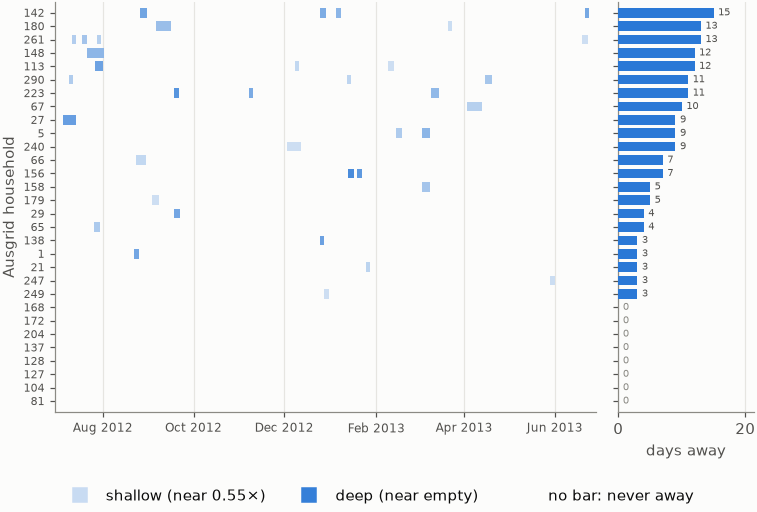

In [10]:
### Where the absences are
# So the detection is visible rather than asserted. The previous figure rests on a rule with two numbers in it -- under 0.55 of
# baseline, for three days or more -- and a rule with numbers in it reads as a
# rule that was tuned until the result appeared. Two things answer that. This
# map, so a reader can see that the runs are long, sparse and spread over
# twenty-two houses rather than being a handful of flagged singletons; and the
# sensitivity table printed beneath it, which is the neighbourhood of those two
# numbers and shows the finding does not live on either of them.
#
# Bars are shaded by DEPTH, light to dark, on the one hue: an absence at 0.5
# of baseline and one at 0.15 are the same event class and a different amount
# of it, which is what a sequential ramp says and two categorical colours do
# not.
runs = an.absence_runs(panel)
if not (runs.empty):
    days = (runs.groupby("hh")["days"].sum()
            .reindex(sorted(panel["hh"].unique()), fill_value=0)
            .sort_values())
    ypos = {hh: i for i, hh in enumerate(days.index)}
    cmap = pf.ramp(fs.TARIFF_COLOR["AU"], "depth")

    fig, (ax, ax_n) = plt.subplots(
        1, 2, figsize=pf.figsize(ratio=0.72), width_ratios=[4.0, 1.0],
        sharey=True)
    lo, hi = panel["day"].min(), panel["day"].max()
    for _, r in runs.iterrows():
        y = ypos[r["hh"]]
        # Depth mapped so the DEEPEST absence is the darkest: `rel` runs from
        # about 0.09 to the 0.55 threshold, and a raw `rel` into the ramp would
        # paint the emptiest house the palest.
        shade = float(np.clip((an.ABSENCE_REL - r["rel"]) / an.ABSENCE_REL,
                              0.12, 1.0))
        ax.barh(y, r["end"] - r["start"] + pd.Timedelta(days=1),
                left=r["start"], height=0.72, color=cmap(0.15 + 0.85 * shade),
                zorder=3)
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.set_yticks(list(ypos.values()), [h.split()[-1] for h in ypos])
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(-0.8, len(ypos) - 0.2)
    ax.grid(axis="y", visible=False)
    finish(ax, ylabel="Ausgrid household")

    # HOW MANY DAYS EACH HOUSE CONTRIBUTES, beside the map: the map shows when,
    # and a reader then wants how much. Zero-length rows are drawn as a tick at
    # zero rather than left blank, so "this house was never away" is a mark and
    # not a gap that could be a rendering failure.
    for hh, d in days.items():
        y = ypos[hh]
        if d:
            ax_n.barh(y, d, height=0.72, color=fs.TARIFF_COLOR["AU"], zorder=3)
            ax_n.annotate(f"{int(d)}", xy=(d, y), xytext=(3, 0),
                          textcoords="offset points", ha="left", va="center",
                          fontsize=6.5, color=INK_2)
        else:
            # A ZERO THAT CAN BE SEEN. A marker at x = 0 is drawn on the spine
            # and disappears into it, so the eight households that were never
            # away read as eight rendering failures.
            ax_n.annotate("0", xy=(0, y), xytext=(3, 0),
                          textcoords="offset points", ha="left", va="center",
                          fontsize=6.5, color=MUTED)
    ax_n.set_xlim(0, days.max() * 1.42)
    ax_n.grid(axis="y", visible=False)
    finish(ax_n, xlabel="days away")

    sens = an.absence_sensitivity(panel)
    base = sens[(sens["rel"] == an.ABSENCE_REL)
                & (sens["min_days"] == an.ABSENCE_MIN_DAYS)].iloc[0]
    # SHORT KEYS: three of these at full length is a row wider than the canvas.
    # What the shades and the empty rows mean at length is in the caption.
    keys = [Line2D([], [], marker="s", ls="", ms=9, color=cmap(0.28),
                   label=f"shallow (near {an.ABSENCE_REL:.2f}×)"),
            Line2D([], [], marker="s", ls="", ms=9, color=cmap(0.95),
                   label="deep (near empty)"),
            Line2D([], [], ls="", marker="", color=MUTED,
                   label="no bar: never away")]
    pf.chart_frame(
        fig,
        f"{len(runs)} absences across {runs['hh'].nunique()} of "
        f"{panel['hh'].nunique()} households, {int(base['days'])} days in all "
        f"({base['pct_of_panel']:.1f} % of the panel) -- long, sparse, and "
        f"spread over the year rather than a handful of flagged singletons",
        subtitle=f"A run is {an.ABSENCE_MIN_DAYS} or more consecutive days under "
                 f"{an.ABSENCE_REL:.2f} of the household's own centred "
                 f"{an.ABSENCE_WINDOW}-day rolling median. The median is what "
                 f"makes a long run detectable at all: a rolling MEAN is dragged "
                 f"down by the absence it is measuring and the run partly hides "
                 f"itself. The sensitivity of the count to both thresholds is "
                 f"printed below the figure",
        handles=keys, ncol=3)
    print(sens.to_string(index=False))
    print(f"\nAt the rule this study uses ({an.ABSENCE_REL} / "
          f"{an.ABSENCE_MIN_DAYS} d): {int(base['runs'])} runs, "
          f"{int(base['households'])} households, {int(base['days'])} days.")
    pf.show(fig, "absence_map", layout="frame")
else:
        print("no absence runs detected")

## 4. Checking the figures mechanically

Overlapping labels, text clipped at the canvas edge and annotations sitting on
somebody else's marker are not reliably visible in a casual read, and are cut in
the exported PDF. The cell below measures them.

In [11]:
### The defect checker, so a later pass does not have to rebuild it
# A GEOMETRY CHECK, committed so it does not have to be rebuilt the next time a
# figure moves. The defects it catches -- a legend row 4 px past the canvas, a
# label ladder that puts seven names on each other, a twin axis drawing a second
# copy of every date tick -- are not visible at a glance.
#
# Three classes:
#   overlap    two text boxes that intersect
#   clipped    text outside the renderer box. For layout="frame" `save_fig`
#              exports with tight=False, so this is GENUINELY cut in the PDF --
#              and a PNG saved with `bbox_inches` unset is trimmed instead,
#              which hides exactly this class. Only the rcParam turns it off.
#   on-marker  a text box sitting on somebody else's scatter point, which a
#              text-only check cannot see at all
#
# GHOSTS FIRST. A locator routinely emits ticks beyond the view limits; they are
# never drawn, but their Text artists have positions, and on a right-hand panel
# they sit past the canvas edge. Reported, they are clipped labels a reader
# cannot find in the image. They must be dropped from BOTH sweeps below: filtered
# out of the per-axes one alone, the figure-level sweep picks them back up.
from matplotlib.text import Text
from matplotlib.collections import PathCollection

PAD = 1.0        # px of slack: two boxes that merely touch are not a defect


def live_texts(fig):
    out, all_ghosts = [], set()
    for ax in fig.axes:
        ghosts = set()
        for axis, lims in ((ax.xaxis, ax.get_xlim()), (ax.yaxis, ax.get_ylim())):
            lo, hi = sorted(lims)
            for tick in axis.get_major_ticks() + axis.get_minor_ticks():
                if not (lo - 1e-9 <= tick.get_loc() <= hi + 1e-9):
                    ghosts |= {id(l) for l in (tick.label1, tick.label2) if l}
        all_ghosts |= ghosts
        out += [t for t in ax.findobj(Text)
                if id(t) not in ghosts and t.get_text().strip() and t.get_visible()]
    seen = {id(t) for t in out} | all_ghosts
    out += [t for t in fig.findobj(Text)
            if id(t) not in seen and t.get_text().strip() and t.get_visible()]
    return out


def check(fig, name):
    # A CLOSED FIGURE HAS NO RENDERER. `plt.close("all")` -- which the inline
    # backend runs after every cell -- swaps the figure's canvas for a bare
    # `FigureCanvasBase`, and asking that for a renderer is an AttributeError.
    # Attaching a fresh Agg canvas gives the Figure back everything the measure
    # needs and changes nothing about the export, which already happened.
    if not hasattr(fig.canvas, "get_renderer"):
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        FigureCanvasAgg(fig)
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    box = fig.get_window_extent()
    boxes = []
    for t in live_texts(fig):
        try:
            boxes.append((t, t.get_window_extent(r)))
        except Exception:
            pass
    bad = []
    for i, (t1, b1) in enumerate(boxes):
        if (b1.x0 < -PAD or b1.y0 < -PAD
                or b1.x1 > box.width + PAD or b1.y1 > box.height + PAD):
            bad.append(f"CLIPPED  {t1.get_text()[:44]!r}")
        for t2, b2 in boxes[i + 1:]:
            if (b1.x0 < b2.x1 - PAD and b2.x0 < b1.x1 - PAD
                    and b1.y0 < b2.y1 - PAD and b2.y0 < b1.y1 - PAD):
                bad.append(f"OVERLAP  {t1.get_text()[:26]!r} x {t2.get_text()[:26]!r}")
    for ax in fig.axes:
        pts = [ax.transData.transform(np.asarray(c.get_offsets()))
               for c in ax.collections
               if isinstance(c, PathCollection) and len(c.get_offsets())]
        if not pts:
            continue
        P = np.vstack(pts)
        ticks = set(map(id, ax.get_xticklabels())) | set(map(id, ax.get_yticklabels()))
        for t in ax.findobj(Text):
            if id(t) in ticks or not t.get_text().strip() or not t.get_visible():
                continue
            try:
                b = t.get_window_extent(r)
            except Exception:
                continue
            n = int(((P[:, 0] > b.x0) & (P[:, 0] < b.x1)
                     & (P[:, 1] > b.y0) & (P[:, 1] < b.y1)).sum())
            if n:
                bad.append(f"ON-MARKER {t.get_text()[:32]!r} covers {n} point(s)")
    bad = list(dict.fromkeys(bad))
    print(f"{name:<52s} {'clean' if not bad else str(len(bad)) + ' defect(s)'}")
    for line in bad:
        print("   " + line)
    return len(bad)


# Every figure this notebook drew, under the export name it was saved as -- the
# setup cell keeps the list, because the inline backend has closed all of them
# by now and `plt.get_fignums()` is empty.
_total = sum(check(_f, _name or "unnamed") for _f, _name in FIGURES)
print(f"\n{_total} report(s) over {len(FIGURES)} figure(s).")
print("What is left is one accepted class: the numbered badges on the "
      "skill/regret panels,\ndrawn on a surface pad, each cover one to five "
      "points of a 210-point cloud. There is\nno placement in that panel that "
      "covers none, and the pad keeps the digit legible over\nwhat it covers. "
      "Anything else this cell prints is a defect to fix, not to accept.")

skill_vs_regret                                      7 defect(s)
   ON-MARKER '1' covers 2 point(s)
   ON-MARKER '2' covers 1 point(s)
   ON-MARKER '3' covers 1 point(s)
   ON-MARKER '4' covers 5 point(s)
   ON-MARKER '6' covers 1 point(s)
   ON-MARKER '7' covers 2 point(s)
   ON-MARKER 'AU\nbetween methods, n = 7: ρ -0.' covers 1 point(s)
household_heterogeneity                              clean
forecast_channel_regret                              clean
forecast_channel_regret_lifetime                     clean
top_methods_headtohead                               clean
top_methods_channels                                 clean
holiday_effect                                       clean
absence_forecast_breakdown                           clean
absence_map                                          clean

7 report(s) over 9 figure(s).
What is left is one accepted class: the numbered badges on the skill/regret panels,
drawn on a surface pad, each cover one to five points of a 210-point cl